# 🌳 Tree Models — Training & Evaluation
**Models:** Decision Tree · Random Forest · XGBoost  
**Strategy:** With SMOTE vs Without SMOTE · GridSearchCV tuning



## 📦 Imports

In [1]:
# ── CELL 1: Imports ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, f1_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# ── CELL 2: Load data ──────────────────────────────────────
BASE = r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree"

X_train = pd.read_csv(os.path.join(BASE, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(BASE, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(BASE, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(BASE, 'y_test.csv')).squeeze()

# ── CELL 3: Drop leaky columns ────────────────────────────
leaky = ['Recency', 'TenureRatio', 'RFMSegment']
X_train = X_train.drop(columns=[c for c in leaky if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in leaky if c in X_test.columns])

print("Shape:", X_train.shape)
print("Leaky cols remaining:", [c for c in leaky if c in X_train.columns])  # must be []

# ── CELL 4: SMOTE ─────────────────────────────────────────
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())

Shape: (3497, 63)
Leaky cols remaining: []
Before SMOTE: {0: 2334, 1: 1163}
After  SMOTE: {0: 2334, 1: 2334}


In [2]:
# Colonnes numériques
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print("Numériques:", numeric_cols)

Numériques: ['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'SupportTicketsCount', 'SatisfactionScore', 'AgeCategory', 'SpendingCategory', 'PreferredTimeOfDay', 'LoyaltyLevel', 'BasketSizeCategory', 'Country', 'RegYear', 'RegMonth', 'GeoIP', 'CountryMismatch', 'MonetaryPerDay', 'AvgBasketValue', 'CancelRate', 'ProductsPerTrans', 'FavoriteSeason_Automne', 'FavoriteSeason_Hiver', 'FavoriteSeason_Printemps', 'FavoriteSeason_Été', 'WeekendPreference_Inconnu', 'WeekendPreference_Semaine', 'WeekendPreference_Weekend', 'ProductDiversity_Explorateur', 'ProductDiversity_Modéré', 'P

## Negative Behavior clustering

In [6]:
Nfeatures=['ReturnRatio', 'NegativeQuantityCount', 'CancelRate']

In [7]:
from sklearn.preprocessing import StandardScaler

N_X_scaled = StandardScaler().fit_transform(X_train[Nfeatures])
from sklearn.cluster import KMeans

kmeansneg = KMeans(n_clusters=3, random_state=42)
labels = kmeansneg.fit_predict(N_X_scaled)
from sklearn.metrics import silhouette_score

print(silhouette_score(N_X_scaled, labels))

0.8466116174255304


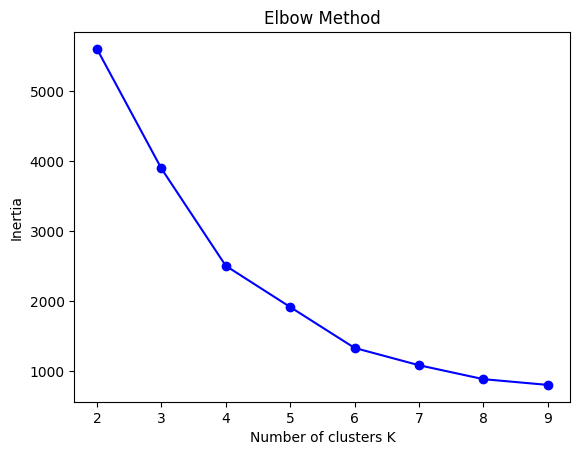

In [6]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(N_X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [38]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(N_X_scaled)
    score = silhouette_score(N_X_scaled, labels)
    print(f'K={k} → Silhouette: {score:.3f}')

K=2 → Silhouette: 0.894
K=3 → Silhouette: 0.847
K=4 → Silhouette: 0.817
K=5 → Silhouette: 0.811
K=6 → Silhouette: 0.766
K=7 → Silhouette: 0.766


   ReturnRatio  NegativeQuantityCount  CancelRate
0     1.787334               2.218191    2.191140
1    -0.178720              -0.126796   -0.190452
2     8.830356               0.203628    7.582496


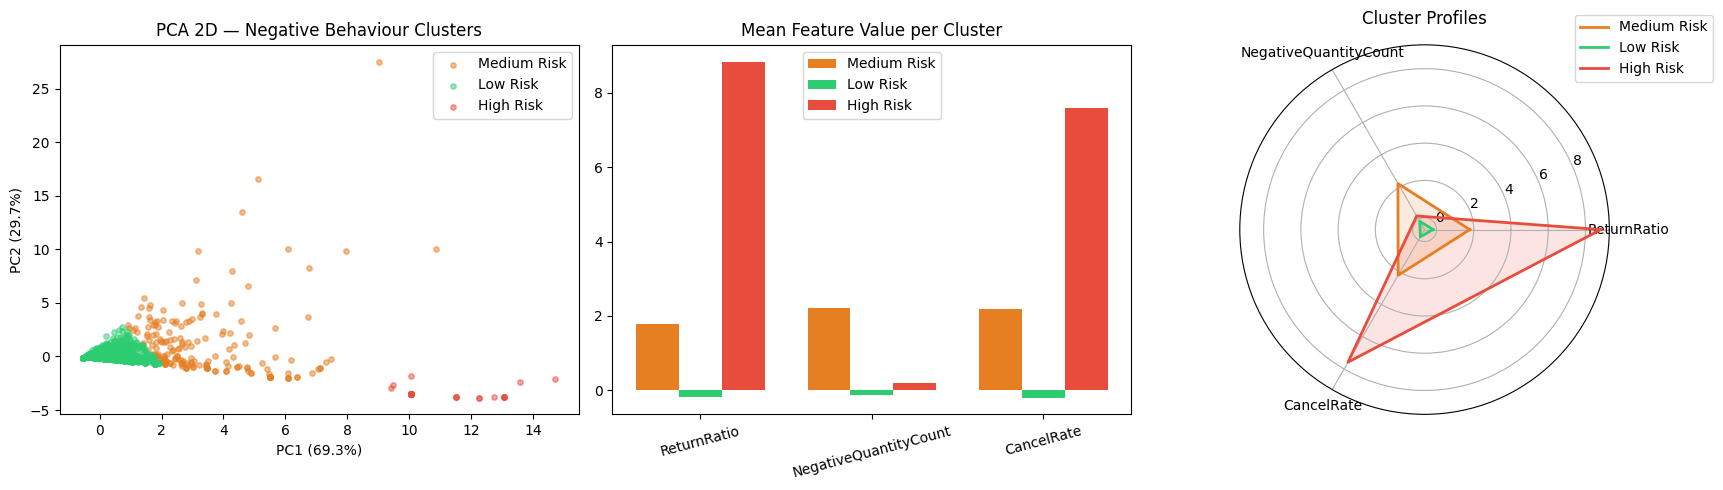

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Refit with K=3
kmeans3 = KMeans(n_clusters=3, random_state=42)
labels3 = kmeans3.fit_predict(N_X_scaled)

# Cluster names based on mean profiles
cluster_df = pd.DataFrame(N_X_scaled, columns=Nfeatures)
cluster_df['Cluster'] = labels3
means = cluster_df.groupby('Cluster')[Nfeatures].mean()
# Manual label mapping based on cluster centers
centers = pd.DataFrame(kmeans3.cluster_centers_, columns=Nfeatures)
print(centers)  # run this first to see which cluster index = which risk



#Cluster 0 → moderate-high values  → Medium Risk  🟠
#Cluster 1 → all near zero         → Low Risk     🟢
#Cluster 2 → extremely high        → High Risk    🔴

# --- Plot 1: PCA 2D Scatter ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(N_X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
label_map = {
    0: 'Medium Risk',
    1: 'Low Risk',
    2: 'High Risk'
}
color_map = {
    'Low Risk':    '#2ecc71',  # green
    'Medium Risk': '#e67e22',  # orange
    'High Risk':   '#e74c3c'   # red
}


# Map cluster index to risk level by mean ProblemRatio
order = means['ReturnRatio'].argsort().values  # 0=low, 1=med, 2=high
label_map = {order[i]: labels_names[i] for i in range(3)}

# Plot 1 — PCA scatter
for c in range(3):
    mask = (labels3 == c) 
    name = label_map[c]

    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color_map[name],
                    label=name, alpha=0.5, s=15)
axes[0].set_title('PCA 2D — Negative Behaviour Clusters')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Plot 2 — Bar chart: mean per feature per cluster
x = np.arange(len(Nfeatures))
width = 0.25
for i, c in enumerate(range(3)):
    name = label_map[c]
    axes[1].bar(x + c*width, means.loc[c], width,
                label=name, color=color_map[name])
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(Nfeatures, rotation=15)
axes[1].set_title('Mean Feature Value per Cluster')
axes[1].legend()

# Plot 3 — Radar chart
from matplotlib.patches import FancyArrowPatch
angles = np.linspace(0, 2*np.pi, len(Nfeatures), endpoint=False).tolist()
angles += angles[:1]

axes[2].remove()
ax_radar = fig.add_subplot(133, polar=True)
for i, c in enumerate(range(3)):
    values = means.loc[c].tolist()
    values += values[:1]
    ax_radar.plot(angles, values, color=colors[order.tolist().index(c)],
                  linewidth=2, label=label_map[c])
    ax_radar.fill(angles, values, color=colors[order.tolist().index(c)], alpha=0.15)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(Nfeatures)
ax_radar.set_title('Cluster Profiles', pad=15)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

Business meaning with K=3 you get three actionable segments:

Low risk — normal customers
Medium risk — occasional returns/cancellations
High risk — chronic returners / fraudulent behaviour

In [7]:
cluster_features = [
    
    'Frequency',
    'MonetaryTotal',
    'AvgBasketValue',
    'AvgDaysBetweenPurchases'
]
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_train[cluster_features])
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
from sklearn.metrics import silhouette_score

print(silhouette_score(X_scaled, labels))


0.8879385524512218


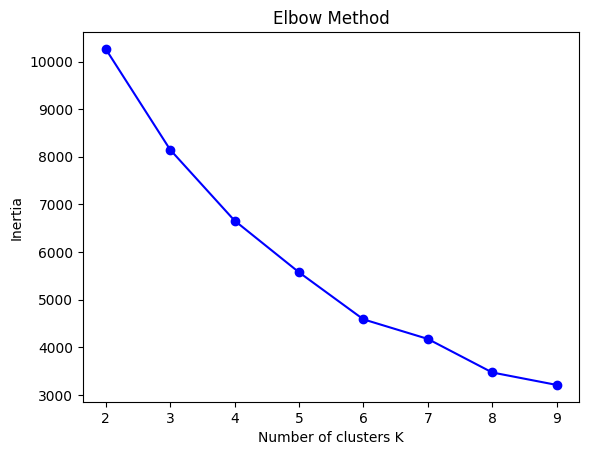

In [8]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [41]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'K={k} → Silhouette: {score:.3f}')

K=2 → Silhouette: 0.907
K=3 → Silhouette: 0.888
K=4 → Silhouette: 0.813
K=5 → Silhouette: 0.546
K=6 → Silhouette: 0.470
K=7 → Silhouette: 0.530


In [96]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model', smote=False):
    label = f"{model_name} {'+ SMOTE' if smote else '(no SMOTE)'}"

    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    print('\n' + '='*55)
    print(f'  {label}')
    print('='*55)
    print(classification_report(y_te, y_pred, digits=4))  # ← add digits=4 here
    print(f'  Train accuracy: {model.score(X_tr, y_tr)}')  # ← add train accuracy
    print(f'  Test  accuracy: {model.score(X_te, y_te)}')  # ← add test accuracy

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {label}')

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_te, y_proba)
        auc = roc_auc_score(y_te, y_proba)
        axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}')
        axes[1].plot([0,1], [0,1], '--', color='gray')
        axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
        axes[1].set_title(f'ROC Curve — {label}')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        'model':        label,
        'f1':           f1_score(y_te, y_pred, average='weighted'),
        'auc':          roc_auc_score(y_te, y_proba) if y_proba is not None else None,
        'fitted_model': model
    }

---
# 🌿 1. Decision Tree
### 1.1 Baseline (no tuning)


  Decision Tree (no SMOTE)
              precision    recall  f1-score   support

           0     0.9598    0.9401    0.9498       584
           1     0.8845    0.9210    0.9024       291

    accuracy                         0.9337       875
   macro avg     0.9221    0.9305    0.9261       875
weighted avg     0.9347    0.9337    0.9340       875

  Train accuracy: 1.0
  Test  accuracy: 0.9337142857142857


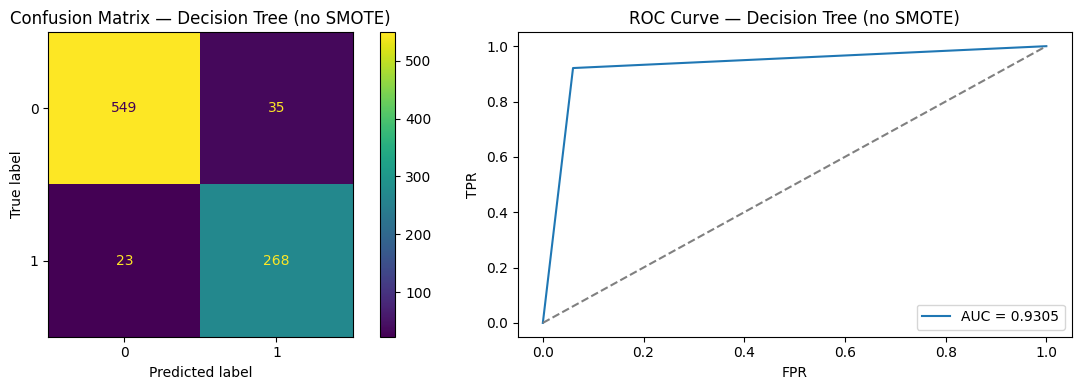

ValueError: Number of labels=4668 does not match number of samples=3497

In [128]:
# Without SMOTE
res_dt_no = evaluate_model(
    DecisionTreeClassifier(random_state=42),
    X_train_clean, y_train, X_test_clean, y_test,
    model_name='Decision Tree', smote=False)

# With SMOTE
res_dt_sm = evaluate_model(
    DecisionTreeClassifier(random_state=42),
    X_train_clean, y_train_bal, X_test_clean, y_test,
    model_name='Decision Tree', smote=True)

In [129]:
from sklearn.tree import DecisionTreeClassifier

# Train a decision tree (or use your existing one)
dt = DecisionTreeClassifier(random_state=42, max_depth=1)  # max_depth=1 for single split
dt.fit(X_train, y_train)

# Get the most important feature (root split)
feature_importances = dt.feature_importances_
most_important_idx = feature_importances.argmax()
most_important_feature = X_train.columns[most_important_idx]

print(f"Most important feature: {most_important_feature}")
print(f"Importance score: {feature_importances[most_important_idx]:.4f}")

Most important feature: FavoriteSeason_Automne
Importance score: 1.0000


In [125]:
drop=['FavoriteSeason_Automne', 'FavoriteSeason_Hiver', 'FavoriteSeason_Printemps', 'FavoriteSeason_Été']

In [126]:
X_train_clean=X_train.drop(columns=drop)
X_test_clean=X_test.drop(columns=drop)

#Key interpretation
✔ What improved with SMOTE
Recall for churn increased slightly (0.924 → 0.931)

👉 meaning:

model catches a bit more churners
❌ What got worse
Overall accuracy decreased
F1-score for churn decreased
Precision for churn decreased (more false positives)
Model generalization slightly worse

### 1.2 GridSearchCV Tuning

In [68]:
dt_param_grid = {
    'max_depth':         [3, 5, 10,15 ,None],
    'min_samples_split': [2, 10, 20,50],
    'min_samples_leaf':  [1, 5, 10,20],
    'criterion':         ['gini', 'entropy'],
    'class_weight': ['balanced', None],
    'max_features': [None, 'sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Without SMOTE
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
    dt_param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1)
gs_dt.fit(X_train, y_train)
print('Best params (no SMOTE):', gs_dt.best_params_)



Fitting 5 folds for each of 960 candidates, totalling 4800 fits
Best params (no SMOTE): {'class_weight': None, 'criterion': 'entropy', 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}



  Decision Tree Tuned (no SMOTE)
              precision    recall  f1-score   support

           0     0.9605    0.9589    0.9597       584
           1     0.9178    0.9210    0.9194       291

    accuracy                         0.9463       875
   macro avg     0.9392    0.9399    0.9396       875
weighted avg     0.9463    0.9463    0.9463       875

  Train accuracy: 0.9717
  Test  accuracy: 0.9463


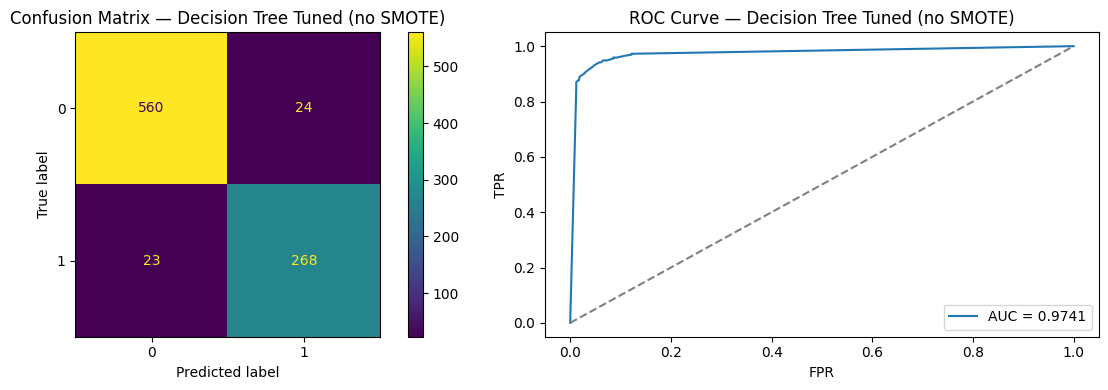

In [69]:
res_dt_tuned_no = evaluate_model(gs_dt.best_estimator_,
    X_train, y_train, X_test, y_test, 'Decision Tree Tuned', smote=False)




  Decision Tree (no SMOTE)
              precision    recall  f1-score   support

           0     0.8600    0.9572    0.9060       584
           1     0.8889    0.6873    0.7752       291

    accuracy                         0.8674       875
   macro avg     0.8744    0.8222    0.8406       875
weighted avg     0.8696    0.8674    0.8625       875

  Train accuracy: 0.8939090649127824
  Test  accuracy: 0.8674285714285714


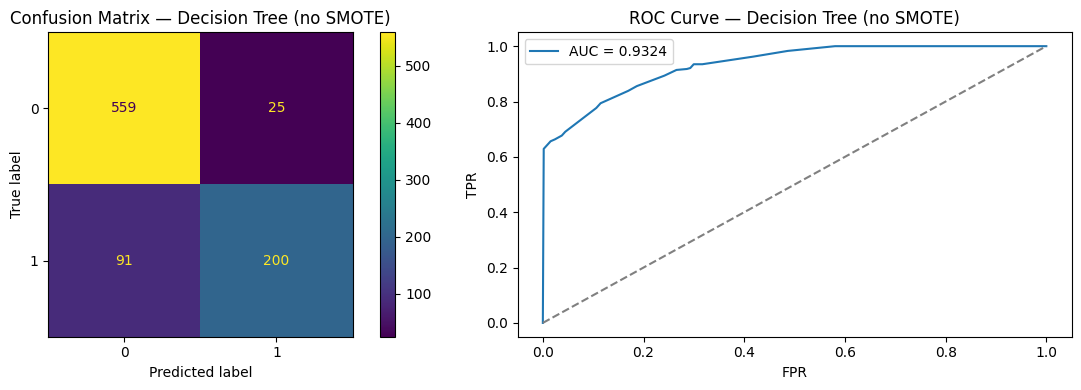

In [106]:
# Without SMOTE
dt= evaluate_model(
   gs_dt.best_estimator_,
    X_train_clean, y_train, X_test_clean, y_test,
    model_name='Decision Tree', smote=False)

In [107]:
dt_param_grid = {
    'max_depth':         [3, 5, 7, 10],  # remove None and 15
    'min_samples_split': [10, 20, 50],   # remove 2
    'min_samples_leaf':  [5, 10, 20],    # remove 1
    'criterion':         ['gini', 'entropy'],
    'class_weight':      ['balanced', None],
    'max_features':      ['sqrt', 'log2']  # remove None
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Without SMOTE
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
    dt_param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1)
gs_dt.fit(X_train, y_train)
print('Best params (no SMOTE):', gs_dt.best_params_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best params (no SMOTE): {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 10}



  Decision Tree (no SMOTE)
              precision    recall  f1-score   support

           0     0.9270    0.9572    0.9419       584
           1     0.9081    0.8488    0.8774       291

    accuracy                         0.9211       875
   macro avg     0.9176    0.9030    0.9097       875
weighted avg     0.9207    0.9211    0.9204       875

  Train accuracy: 0.9399485273091222
  Test  accuracy: 0.9211428571428572


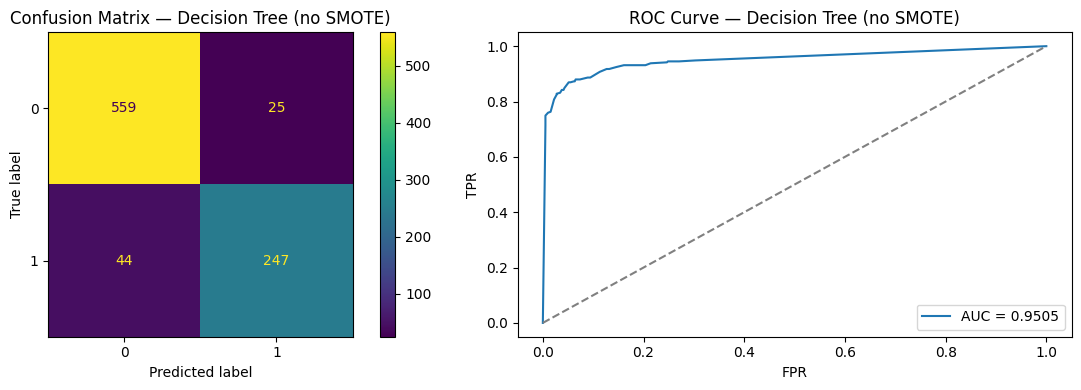

In [108]:
# Without SMOTE
res_dt_tuned_no = evaluate_model(
     gs_dt.best_estimator_,
    X_train, y_train, X_test, y_test,
    model_name='Decision Tree', smote=False)

---
# 🌲 2. Random Forest
### 2.1 Baseline (no tuning)


  Random Forest (no SMOTE)
              precision    recall  f1-score   support

           0     0.9395    0.9846    0.9615       584
           1     0.9658    0.8729    0.9170       291

    accuracy                         0.9474       875
   macro avg     0.9527    0.9287    0.9393       875
weighted avg     0.9483    0.9474    0.9467       875

  Train accuracy: 1.0
  Test  accuracy: 0.9474285714285714


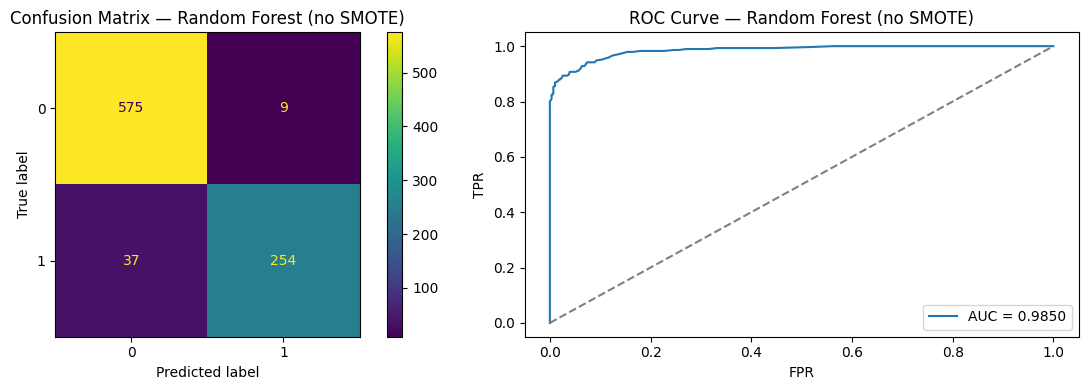

In [109]:
# Without SMOTE
res_rf_no = evaluate_model(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test, 'Random Forest', smote=False)


### 2.2 GridSearchCV Tuning

In [110]:
rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5,7, 8],
    'min_samples_split': [10,20,50],
    'min_samples_leaf':  [5, 10, 20],      # add this, minimum 5
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced', None]

}

# Without SMOTE
gs_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1)
gs_rf.fit(X_train, y_train)
print('Best params (no SMOTE):', gs_rf.best_params_)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best params (no SMOTE): {'class_weight': None, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
res_rf_tuned_no = evaluate_model(gs_rf.best_estimator_,
    X_train, y_train, X_test, y_test, 'Random Forest Tuned', smote=False)



In [119]:
import joblib

joblib.dump(gs_rf.best_estimator_, "rf_tuned_model.pkl")

['rf_tuned_model.pkl']

---
# ⚡ 3. XGBoost
### 3.1 Baseline (no tuning)

scale_pos_weight = 2.01  (neg=2334, pos=1163)

  XGBoost (no SMOTE)
              precision    recall  f1-score   support

           0     0.9662    0.9795    0.9728       584
           1     0.9576    0.9313    0.9443       291

    accuracy                         0.9634       875
   macro avg     0.9619    0.9554    0.9585       875
weighted avg     0.9633    0.9634    0.9633       875

  Train accuracy: 1.0
  Test  accuracy: 0.9634285714285714


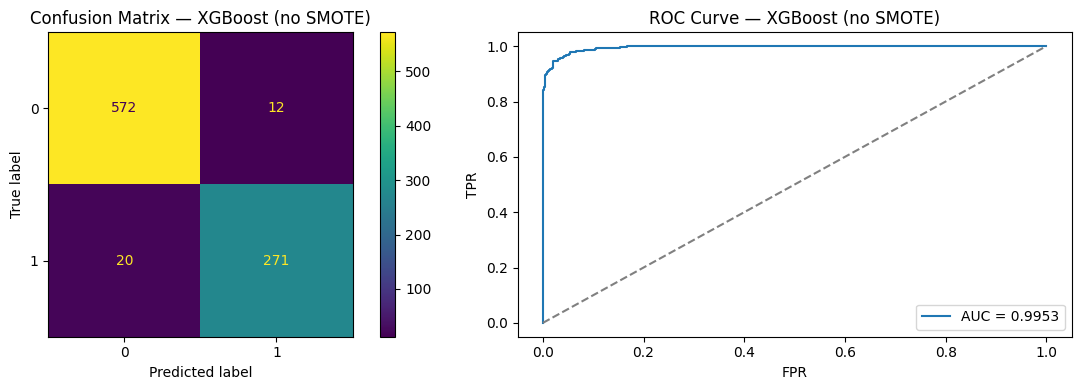

In [101]:
# scale_pos_weight = neg/pos ratio (XGBoost native imbalance handler)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight = {spw:.2f}  (neg={neg}, pos={pos})')

# Without SMOTE — use scale_pos_weight
res_xgb_no = evaluate_model(
    XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=spw),
    X_train, y_train, X_test, y_test, 'XGBoost', smote=False)



### 3.2 GridSearchCV Tuning

In [131]:
# scale_pos_weight = neg/pos ratio (XGBoost native imbalance handler)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

In [132]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

rs = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=spw,
)

rs = RandomizedSearchCV(
    estimator=rs,
    param_distributions={
        'n_estimators': [100, 150, 200,300],
        'max_depth': [ 4],
        'learning_rate': [0.01, 0.02],
        'subsample': [0.6],
        'colsample_bytree': [0.6],
        'min_child_weight': [20],
        'reg_alpha': [0.01, 0.05],
        'reg_lambda': [1.0, 5.0],
        'gamma': [0.1]
    },
    n_iter=40,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

rs.fit(X_train_clean, y_train)
print(rs.best_params_)


{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 20, 'max_depth': 4, 'learning_rate': 0.02, 'gamma': 0.1, 'colsample_bytree': 0.6}



  XGBoost Tuned (no SMOTE)
              precision    recall  f1-score   support

           0     0.9643    0.9709    0.9676       584
           1     0.9408    0.9278    0.9343       291

    accuracy                         0.9566       875
   macro avg     0.9525    0.9494    0.9509       875
weighted avg     0.9565    0.9566    0.9565       875

  Train accuracy: 0.966542750929368
  Test  accuracy: 0.9565714285714285


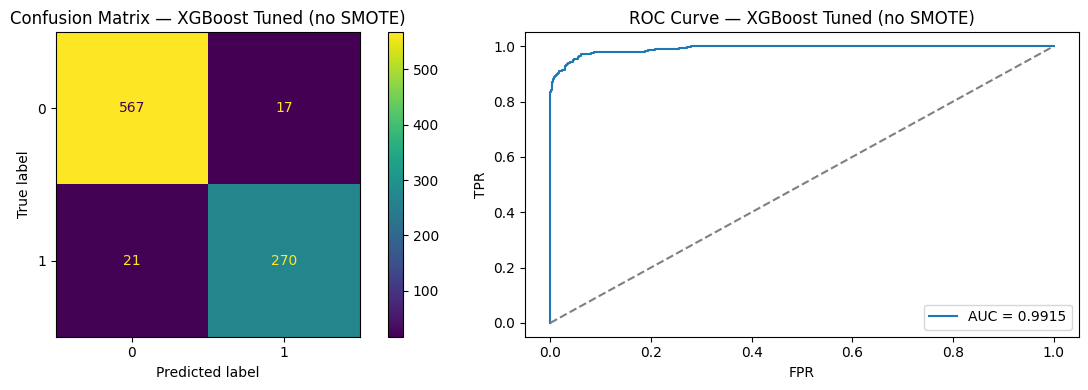

In [133]:
res_xgb_tuned_no = evaluate_model(rs.best_estimator_,
    X_train_clean, y_train, X_test_clean, y_test, 'XGBoost Tuned', smote=False)


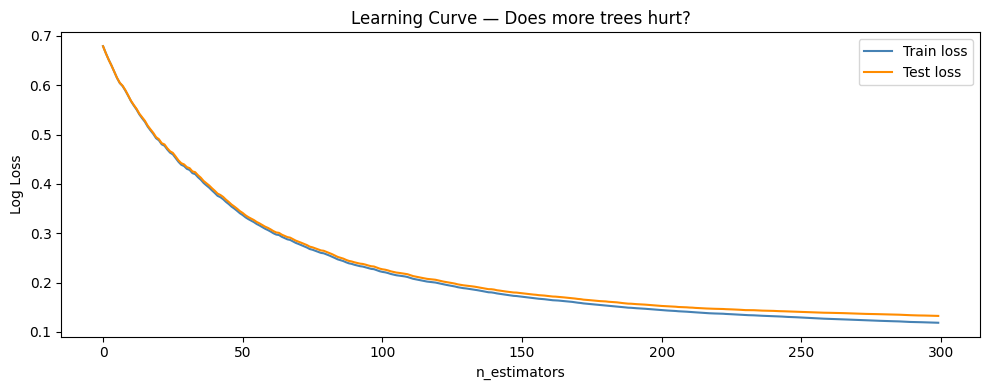

In [136]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Train with staged evaluation
xgb_eval = XGBClassifier(
    **rs.best_params_,              # your best params
    eval_metric='logloss',
    scale_pos_weight=spw,
    random_state=42
)

eval_set = [(X_train_clean, y_train), (X_test_clean, y_test)]

xgb_eval.fit(
    X_train_clean, y_train,
    eval_set=eval_set,
    verbose=False
)

# Plot train vs test loss per tree
results = xgb_eval.evals_result()
train_loss = results['validation_0']['logloss']
test_loss  = results['validation_1']['logloss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train loss', color='steelblue')
plt.plot(test_loss,  label='Test loss',  color='darkorange')
plt.xlabel('n_estimators')
plt.ylabel('Log Loss')
plt.title('Learning Curve — Does more trees hurt?')
plt.legend()
plt.tight_layout()
plt.show()

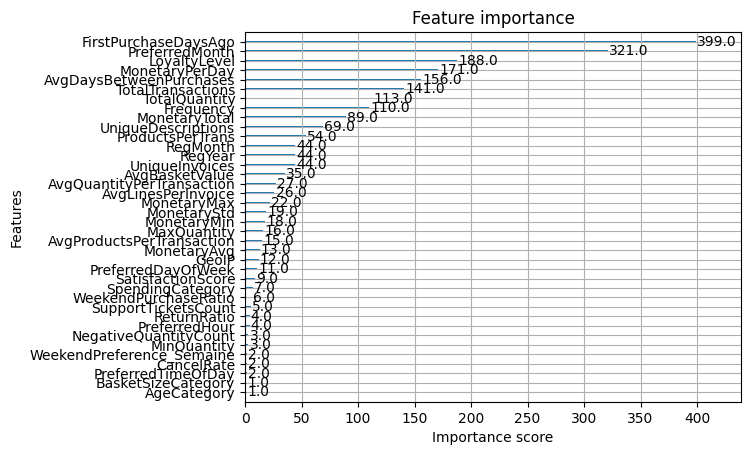

In [137]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(rs.best_estimator_)  # measures frequency (how often used in splits)
plt.show()

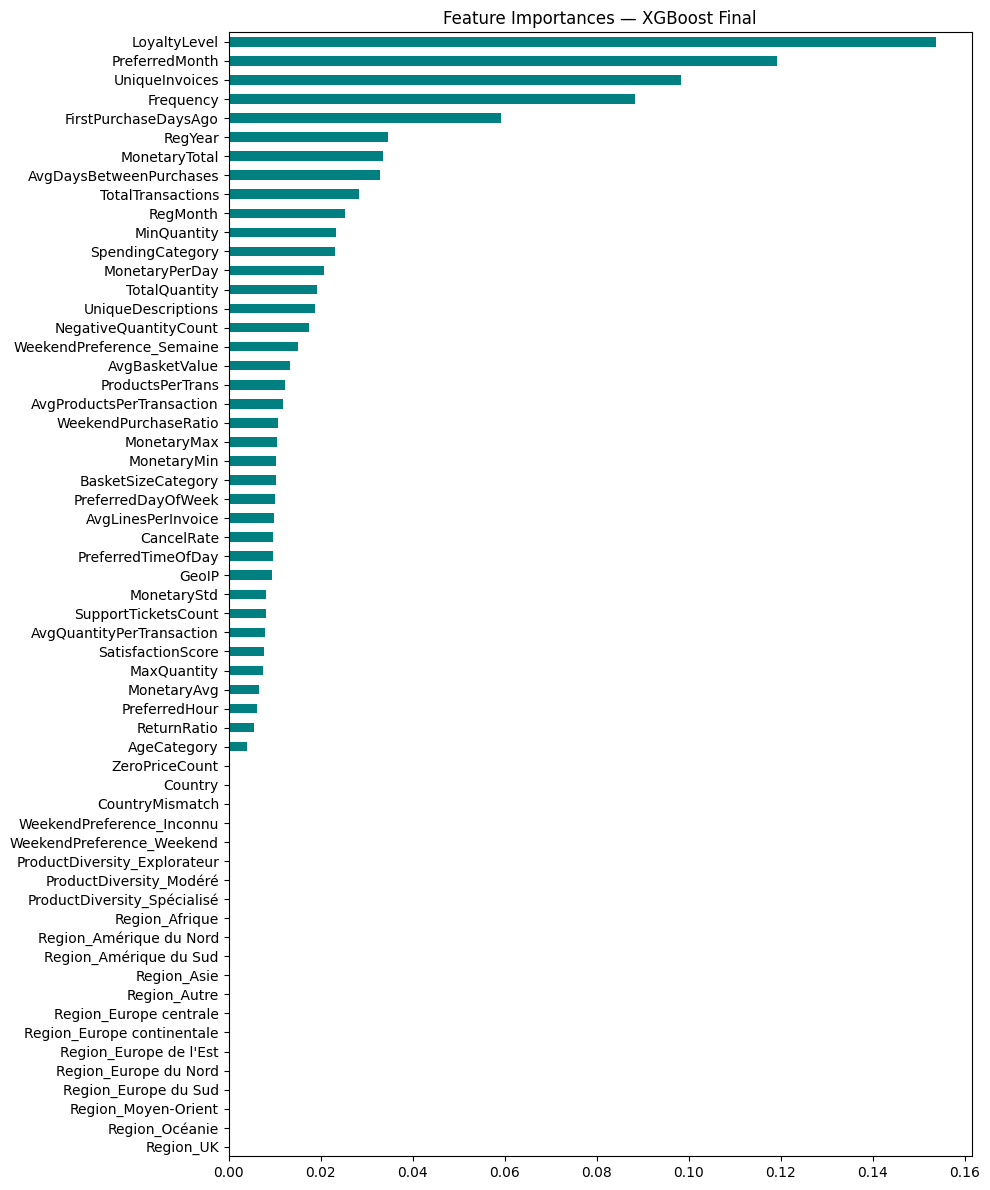

LoyaltyLevel                    0.153781
PreferredMonth                  0.119274
UniqueInvoices                  0.098317
Frequency                       0.088410
FirstPurchaseDaysAgo            0.059287
RegYear                         0.034712
MonetaryTotal                   0.033485
AvgDaysBetweenPurchases         0.032787
TotalTransactions               0.028382
RegMonth                        0.025202
MinQuantity                     0.023341
SpendingCategory                0.022995
MonetaryPerDay                  0.020642
TotalQuantity                   0.019108
UniqueDescriptions              0.018767
NegativeQuantityCount           0.017488
WeekendPreference_Semaine       0.014964
AvgBasketValue                  0.013305
ProductsPerTrans                0.012260
AvgProductsPerTransaction       0.011827
WeekendPurchaseRatio            0.010700
MonetaryMax                     0.010400
MonetaryMin                     0.010334
BasketSizeCategory              0.010169
PreferredDayOfWe

In [138]:
# ── Extract the actual model from the search object ───────
best_xgb = rs.best_estimator_   # ← this is the real XGBoost model

# ── Feature importances ────────────────────────────────────
importances = pd.Series(     #how much it improves model (reduces error)
    best_xgb.feature_importances_,
    index=X_train_clean.columns
).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 12))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importances — XGBoost Final')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print with values
print(importances.to_string())

# Zero and low importance
zero = importances[importances == 0]
low  = importances[(importances > 0) & (importances < 0.01)]
print(f"\nZero importance ({len(zero)}): {zero.index.tolist()}")
print(f"Low  importance ({len(low)}):  {low.index.tolist()}")

In [60]:
# ── Drop zero importance unconditionally ──────────────────
zero_cols = [
    'ZeroPriceCount', 'PreferredTimeOfDay', 'Country', 'CountryMismatch',
    'WeekendPreference_Inconnu', 'WeekendPreference_Semaine', 'BasketSizeCategory',
    'WeekendPreference_Weekend', 'ProductDiversity_Modéré', 'ProductDiversity_Spécialisé',
    'Region_Afrique', 'Region_Amérique du Nord', 'Region_Amérique du Sud',
    'Region_Asie', 'Region_Autre', 'Region_Europe centrale',
    'Region_Europe continentale', "Region_Europe de l'Est", 'Region_Europe du Nord',
    'Region_Europe du Sud', 'Region_Moyen-Orient', 'Region_Océanie', 'Region_UK'
]




X_train_final = X_train_clean.drop(columns=zero_cols)
X_test_final  = X_test_clean.drop(columns=zero_cols)

print(f"Features before : {X_train_clean.shape[1]}")
print(f"Features after  : {X_train_final.shape[1]}")
print(f"Dropped         : {len(zero_cols)}")
print(f"\nRemaining features:\n{X_train_final.columns.tolist()}")

Features before : 57
Features after  : 34
Dropped         : 23

Remaining features:
['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'NegativeQuantityCount', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'SupportTicketsCount', 'SatisfactionScore', 'AgeCategory', 'SpendingCategory', 'RegYear', 'RegMonth', 'GeoIP', 'MonetaryPerDay', 'AvgBasketValue', 'CancelRate', 'ProductsPerTrans', 'ProductDiversity_Explorateur']


In [80]:
xgb_clean = XGBClassifier(
    **rs.best_params_,             # your best params unchanged
    early_stopping_rounds=40,
    eval_metric='logloss',
    scale_pos_weight=spw,
    random_state=42
)

xgb_clean.fit(
    X_train_final, y_train,
    eval_set=[
        (X_train_final, y_train),
        (X_test_final,  y_test)
    ],
    verbose=False
)

train_acc = xgb_clean.score(X_train_final, y_train)
test_acc  = xgb_clean.score(X_test_final,  y_test)

print(f"Features        : {X_train_final.shape[1]}")
print(f"Optimal trees   : {xgb_clean.best_iteration}")
print(f"Train Acc       : {train_acc:.4f}")
print(f"Test  Acc       : {test_acc:.4f}")
print(f"Gap             : {train_acc - test_acc:.4f}")

Features        : 34
Optimal trees   : 299
Train Acc       : 0.9660
Test  Acc       : 0.9486
Gap             : 0.0174


In [81]:
import joblib

joblib.dump(xgb_clean, "xgb_model.pkl")

['xgb_model.pkl']

In [82]:
print(X_train_final.shape)

(3497, 34)


In [83]:
X_train_final.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_train_final.csv", index=False)
X_test_final.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_test_final.csv", index=False)

## Final Model!

In [71]:
# Group 1 — behavioral negatives (likely redundant with CancelRate)
group1 = ['NegativeQuantityCount', 'ReturnRatio',]

# Group 2 — granular quantity stats (redundant with TotalQuantity)
group2 = ['MaxQuantity', 'MinQuantity']

# Group 3 — weak signals
group3 = ['GeoIP', 'SatisfactionScore', 'AgeCategory',
          'PreferredDayOfWeek', 'PreferredHour',
          'MonetaryStd', 'MonetaryAvg',
          'SupportTicketsCount']
group4=['ReturnRatio', 'MinQuantity', 'GeoIP', 'SatisfactionScore', 'AgeCategory',
          'PreferredDayOfWeek', 'PreferredHour',
          'MonetaryStd', 'MonetaryAvg',
          'SupportTicketsCount']

In [72]:
# Test dropping group1 first
X_train_test = X_train_final.drop(columns=group4)
X_test_test  = X_test_final.drop(columns=group4)

xgb_test = XGBClassifier(
    **rs.best_params_,
    early_stopping_rounds=40,
    eval_metric='logloss',
    scale_pos_weight=spw,
    random_state=42
)
xgb_test.fit(
    X_train_test, y_train,
    eval_set=[(X_train_test, y_train), (X_test_test, y_test)],
    verbose=False
)

print(f"Features : {X_train_test.shape[1]}")
print(f"Train    : {xgb_test.score(X_train_test, y_train):.4f}")
print(f"Test     : {xgb_test.score(X_test_test,  y_test):.4f}")
print(f"Gap      : {xgb_test.score(X_train_test, y_train) - xgb_test.score(X_test_test, y_test):.4f}")

Features : 24
Train    : 0.9651
Test     : 0.9520
Gap      : 0.0131


In [84]:
print(X_train_final.columns)

Index(['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd',
       'MonetaryMin', 'MonetaryMax', 'TotalQuantity',
       'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity',
       'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour',
       'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueDescriptions',
       'AvgProductsPerTransaction', 'NegativeQuantityCount', 'ReturnRatio',
       'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice',
       'SupportTicketsCount', 'SatisfactionScore', 'AgeCategory',
       'SpendingCategory', 'RegYear', 'RegMonth', 'GeoIP', 'MonetaryPerDay',
       'AvgBasketValue', 'CancelRate', 'ProductsPerTrans',
       'ProductDiversity_Explorateur'],
      dtype='object')


---
# 📊 4. Final Comparison

In [102]:
results = [
    res_dt_no,        res_dt_sm,
    res_dt_tuned_no,  
    res_rf_no,       
    res_rf_tuned_no,  
    res_xgb_no,      
    res_xgb_tuned_no,
]

df_results = pd.DataFrame([{
    'Model':         r['model'],
    'F1 (weighted)': round(r['f1'], 4),
    'AUC-ROC':       round(r['auc'], 4) if r['auc'] else None
} for r in results])

df_results = df_results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print(df_results.to_string(index=False))

                         Model  F1 (weighted)  AUC-ROC
            XGBoost (no SMOTE)         0.9633   0.9953
      XGBoost Tuned (no SMOTE)         0.9485   0.9850
      Random Forest (no SMOTE)         0.9226   0.9632
Random Forest Tuned (no SMOTE)         0.8974   0.9522
      Decision Tree (no SMOTE)         0.9441   0.9391
         Decision Tree + SMOTE         0.9353   0.9340
      Decision Tree (no SMOTE)         0.8625   0.9324


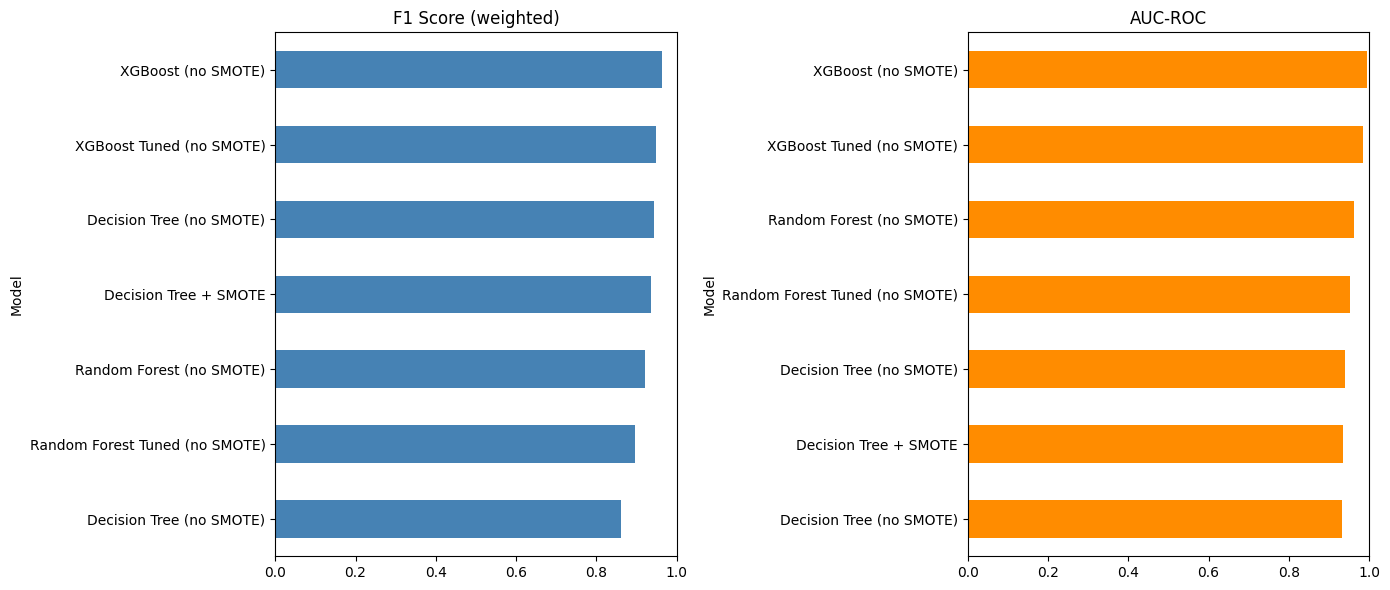

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_results.sort_values('F1 (weighted)').plot(
    x='Model', y='F1 (weighted)', kind='barh', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('F1 Score (weighted)'); axes[0].set_xlim(0, 1)

df_results.sort_values('AUC-ROC').plot(
    x='Model', y='AUC-ROC', kind='barh', ax=axes[1], color='darkorange', legend=False)
axes[1].set_title('AUC-ROC'); axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(r"C:\Users\LENOVO\Desktop\project_ml_retail\reports\model_comparison.png", dpi=150)
plt.show()